# COSC2793 Computational Machine Learning - Assignment 2

This notebook has the outline.


- A. Task and Dataset Understanding
- B. EDA and Data Handling
- C. Model Development and Performance Analysis
- D. Model Comparison
- E. Final Model Selection and Evaluation

In [22]:
# Core imports and config
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# A. Task and Dataset Understanding


We use load the dataset and test dataset to understand the data

In [23]:
# Load data
train_path = './wildfire_cls_train_full.csv'
test_path = './wildfire_cls_test_features.csv'

df = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)

print('Train shape:', df.shape)
print('Test shape:', df_test.shape)
df.head()
# df_test.head()

Train shape: (4340, 20)
Test shape: (1085, 19)


,latitude,longitude,acq_date,acq_time,year,month,season,daynight,region,country,fire_type,satellite,instrument,brightness_k,confidence,temp_max_c,wind_max_kmh,precip_mm,humidity_pct,fire_intensity
0,-22.1967,-61.5275,2024-08-12,1838,2024,NaN,Winter,D,South_America,Peru,Deforestation,Suomi-NPP,VIIRS,360.26,nominal,40.6,39.0,0.11,17.1,Extreme
1,64.2205,-53.4116,2024-07-11,424,2024,7.0,Summer,N,North_America,Canada,Forest,Suomi-NPP,VIIRS,326.20,high,38.9,NaN,0.06,13.2,Low
2,38.6810,9.5739,2024-06-18,546,2024,6.0,Summer,N,Mediterranean,Spain,Wildfire,AQUA,MODIS,343.36,high,36.9,30.1,0.19,35.2,High
3,68.1959,-90.3475,2024-08-26,2240,2024,8.0,Summer,N,North_America,USA,Forest,TERRA,MODIS,389.16,nominal,43.8,17.7,0.98,32.8,Extreme
4,0.6527,118.6227,2025-08-09,2301,2025,8.0,Summer,N,Southeast_Asia,Malaysia,Peatland,TERRA,MODIS,335.68,high,34.8,1.0,0.18,83.2,Moderate


In [24]:
# Check data types
print("\nData types:")
print(df.dtypes)


Data types:
latitude          float64
longitude         float64
acq_date           object
acq_time            int64
year                int64
month             float64
season             object
daynight           object
region             object
country            object
fire_type          object
satellite          object
instrument         object
brightness_k      float64
confidence         object
temp_max_c        float64
wind_max_kmh      float64
precip_mm         float64
humidity_pct      float64
fire_intensity     object
dtype: object


We can see that the dataset includes the numeric and categorical features.

In [25]:
# Check target variable
target_col = "fire_intensity"
y_raw = df[target_col]
print("\nRaw target dtype:", y_raw.dtype)
print("Raw target uniques:", sorted(y_raw.dropna().unique().tolist()))


Raw target dtype: object
Raw target uniques: ['Extreme', 'High', 'Low', 'Moderate']


In [26]:
# Summarize the dataset
print("\nSummary statistics:")
print(df.describe())


Summary statistics:
          latitude    longitude     acq_time         year        month  \
count  4340.000000  4340.000000  4340.000000  4340.000000  3924.000000   
mean      9.821703    29.430626  1177.046774  2024.501843     7.240316   
std      24.321271    78.842700   683.844117     0.500054     2.791615   
min     -42.988300  -167.990600     0.000000  2024.000000     1.000000   
25%      -8.611625   -40.980600   602.000000  2024.000000     5.000000   
50%      10.268500    34.833700  1208.000000  2025.000000     8.000000   
75%      29.011025    95.166775  1752.000000  2025.000000     9.000000   
max      69.930900   153.754900  2359.000000  2025.000000    12.000000   

       brightness_k   temp_max_c  wind_max_kmh    precip_mm  humidity_pct  
count   4013.000000  4340.000000   4133.000000  4340.000000   4340.000000  
mean     336.677742    35.082627     17.508033     2.597111     37.924378  
std       18.539217     5.821218     17.051980     3.062512     18.731153  
min     

We can see the month, brightness_k, wind_max_kmh have the missing values. Then we clarify again by function below.

In [27]:
# Check for missing values
print("\nMissing values in each column:")
print(df.isna().sum())


Missing values in each column:
latitude            0
longitude           0
acq_date            0
acq_time            0
year                0
month             416
season              0
daynight            0
region              0
country             0
fire_type           0
satellite           0
instrument          0
brightness_k      327
confidence          0
temp_max_c          0
wind_max_kmh      207
precip_mm           0
humidity_pct        0
fire_intensity      0
dtype: int64


We encode the target variable fire_intensity into the required 4-class numeric labels (0=Low, 1=Moderate, 2=High, 3=Extreme) to align with the assignment's specifications. This ensures compatibility with evaluation metrics and the final prediction format.

In [28]:
# Mapping target labels to integers
label_to_int = {
    "Low": 0,
    "Moderate": 1,
    "High": 2,
    "Extreme": 3,
}

# Encode target variable
if y_raw.dtype == object:
    y = y_raw.map(label_to_int)
    # Check for unmapped labels
    if y.isna().any():
        unmapped_labels = sorted(y_raw[y.isna()].unique())
        raise ValueError(f"Unmapped target labels found: {unmapped_labels}. Add them to label_to_int.")
else:
    y = pd.to_numeric(y_raw, errors="coerce").astype(int)

We should separate the target variable from the feature set to prevent the data leakage.

In [29]:
dataX = df.drop(columns=[target_col])

# B. EDA and Data Handling

Class counts:
 fire_intensity
0     698
1    1921
2    1340
3     381
Name: count, dtype: int64

Class %:
 fire_intensity
0    16.08
1    44.26
2    30.88
3     8.78
Name: count, dtype: float64


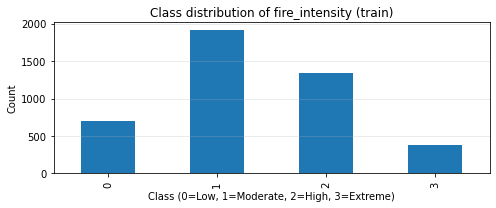

In [30]:
y_ser = pd.Series(y, name="fire_intensity")

counts = y_ser.value_counts().sort_index()
pct = (counts / counts.sum() * 100).round(2)

print("Class counts:\n", counts)
print("\nClass %:\n", pct)

plt.figure(figsize=(7, 3))
counts.plot(kind="bar")
plt.title("Class distribution of fire_intensity (train)")
plt.xlabel("Class (0=Low, 1=Moderate, 2=High, 3=Extreme)")
plt.ylabel("Count")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

The target is imbalanced: class 1 dominates while class 3 is the smallest class. Therefore, a model might perform well on the majority class but poorly on the minority class.

The "acq_date" is string, and acq_time is HHMM. We convert them into numberic values which improves the model usability and avoids traeing time as arbitrary interger.

In [31]:
def make_features(df_features: pd.DataFrame) -> pd.DataFrame:
    X = df_features.copy()

    # --- acq_date -> datetime -> numeric features ---

    X["acq_date_dt"] = pd.to_datetime(X["acq_date"], errors="coerce")
    X["acq_month_from_date"] = X["acq_date_dt"].dt.month
    X["acq_dayofyear"] = X["acq_date_dt"].dt.dayofyear
    X["acq_weekday"] = X["acq_date_dt"].dt.weekday

    # Drop the raw string date 
    X = X.drop(columns=["acq_date", "acq_date_dt"])

    # --- acq_time (HHMM) -> hour/minute/minutes_since_midnight ---
    # Ensure numeric first (handles weird formatting safely)
    t = pd.to_numeric(X["acq_time"], errors="coerce")
    X["acq_hour"] = (t // 100).astype("Int64")
    X["acq_minute"] = (t % 100).astype("Int64")

    X["acq_minutes_since_midnight"] = (X["acq_hour"] * 60 + X["acq_minute"]).astype("Int64")

    # Drop original HHMM integer
    X = X.drop(columns=["acq_time"])

    if "month" in X.columns:
        X = X.drop(columns=["month"])

    return X

X_all = make_features(df.drop(columns=[target_col]))
X_submit = make_features(df_test)

We explore the numberic features to detect the distribution, analyze the skewness and identify the outliers.

Numeric columns with missing values:


,missing
brightness_k,327
wind_max_kmh,207


Numeric columns plotted: ['brightness_k', 'temp_max_c', 'humidity_pct', 'wind_max_kmh', 'precip_mm', 'latitude', 'longitude', 'acq_hour', 'acq_dayofyear']


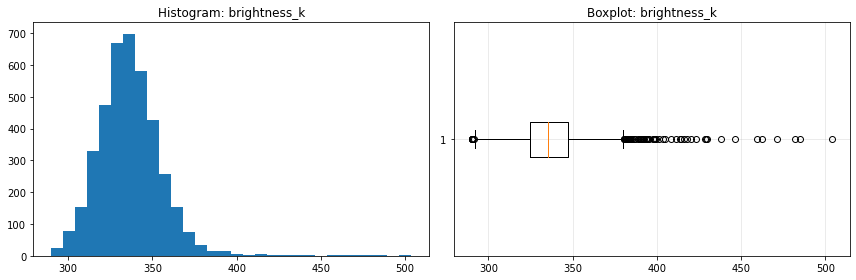

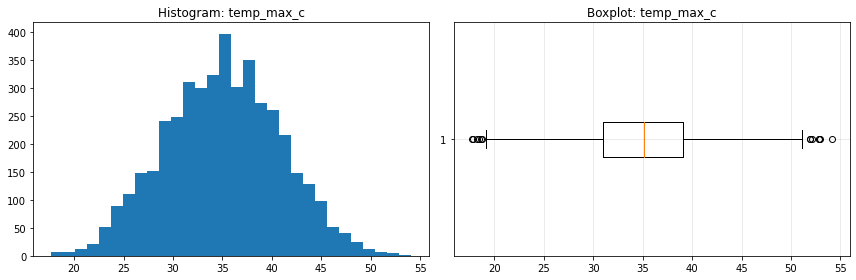

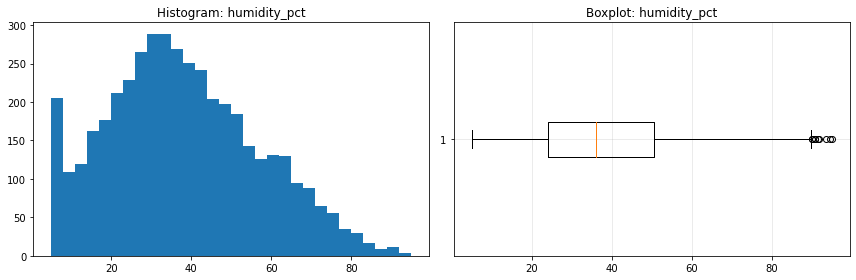

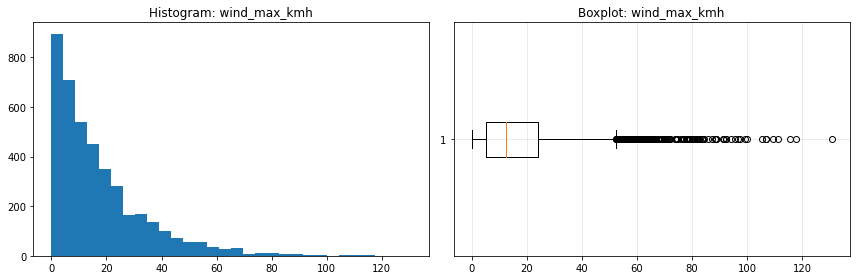

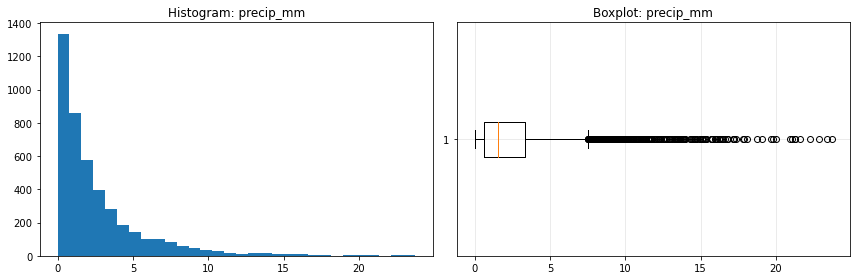

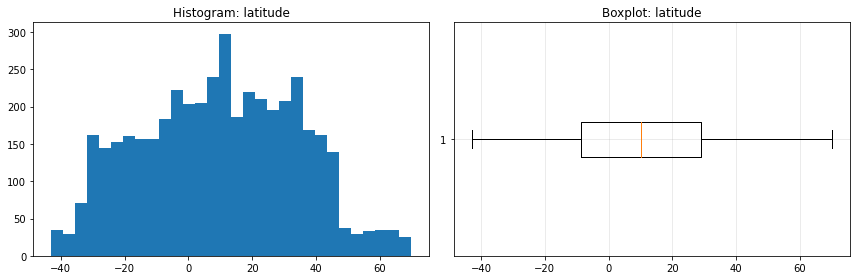

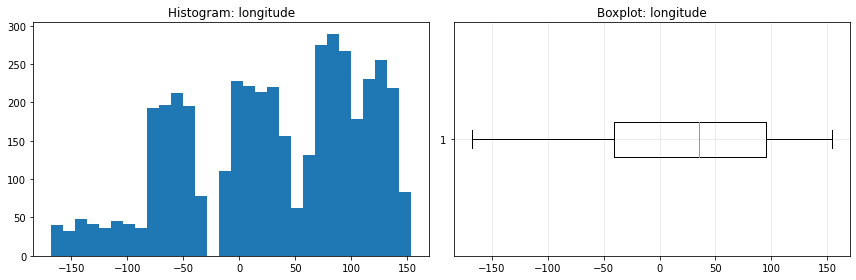

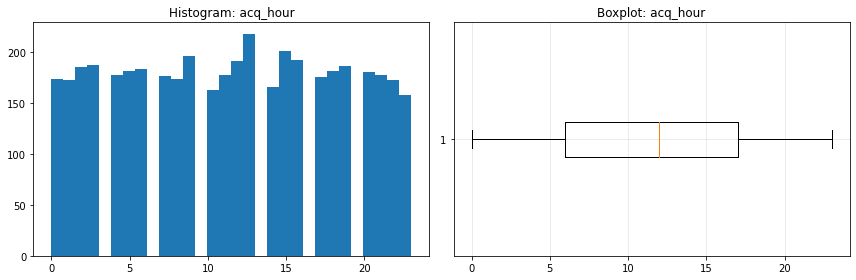

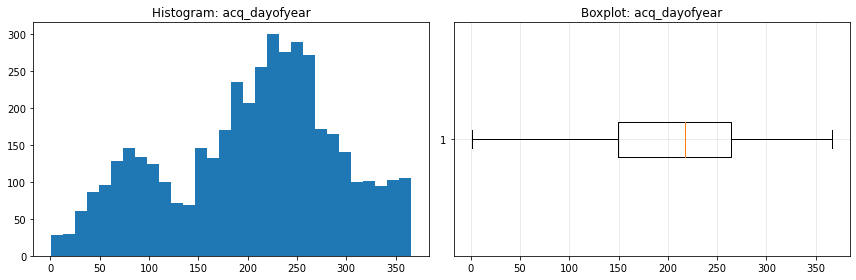

In [34]:
# # Explore numeric features
# numeric_cols = X_all.select_dtypes(include=[np.number]).columns.tolist()

# for col in numeric_cols:
#     plt.figure(figsize=(12, 5))

#     # Histogram
#     plt.subplot(1, 2, 1)
#     X_all[col].dropna().hist(bins=30, color='skyblue', edgecolor='black')
#     plt.title(f"Histogram of {col}")
#     plt.xlabel(col)
#     plt.ylabel("Frequency")
#     plt.grid(axis="y", alpha=0.3)

#     # Boxplot
#     plt.subplot(1, 2, 2)
#     plt.boxplot(X_all[col].dropna(), vert=False, patch_artist=True, boxprops=dict(facecolor='lightgreen'))
#     plt.title(f"Boxplot of {col}")
#     plt.xlabel(col)

#     plt.tight_layout()
#     plt.show()

#     # Print summary statistics
#     print(f"Feature: {col}")
#     print(f"  Mean: {X_all[col].mean():.2f}, Median: {X_all[col].median():.2f}")
#     print(f"  Skewness: {X_all[col].skew():.2f}")
#     print(f"  Missing values: {X_all[col].isna().sum()}")
#     print()

# Numeric columns EDA (choose a manageable subset)
num_cols = X_all.select_dtypes(include=[np.number]).columns.tolist()

# 1) Columns with missing values
missing_counts = X_all[num_cols].isna().sum().sort_values(ascending=False)
missing_cols = missing_counts[missing_counts > 0].index.tolist()

print("Numeric columns with missing values:")
display(pd.DataFrame({"missing": missing_counts[missing_counts > 0]}))

# 2) Pick a small, interpretable set for plots
preferred = [
    "brightness_k", "temp_max_c", "humidity_pct", "wind_max_kmh", "precip_mm",
    "latitude", "longitude",
    "acq_hour", "acq_dayofyear"
]
plot_cols = [c for c in preferred if c in num_cols]

print("Numeric columns plotted:", plot_cols)

# 3) Plot distributions + boxplots for the chosen subset

for col in plot_cols:
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    X_all[col].dropna().hist(bins=30, ax=ax[0])
    ax[0].set_title(f"Histogram: {col}")
    ax[0].grid(alpha=0.3)

    ax[1].boxplot(X_all[col].dropna(), vert=False)
    ax[1].set_title(f"Boxplot: {col}")
    ax[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

Use median for the numeric missing values (so: brightness_k and wind_max_kmh):
- wind_max_kmh: the histogram is strongly right‑skewed with a long tail + many outliers in the boxplot → mean will be pulled up, median is robust → median is the better default.
- brightness_k: looks closer to bell-shaped, but your boxplot still shows outliers on the high end. Mean could work, but median is still safe and keeps your preprocessing consistent across numeric features.

Then we analyze correlations between features and with the target variable which helps find the important features.

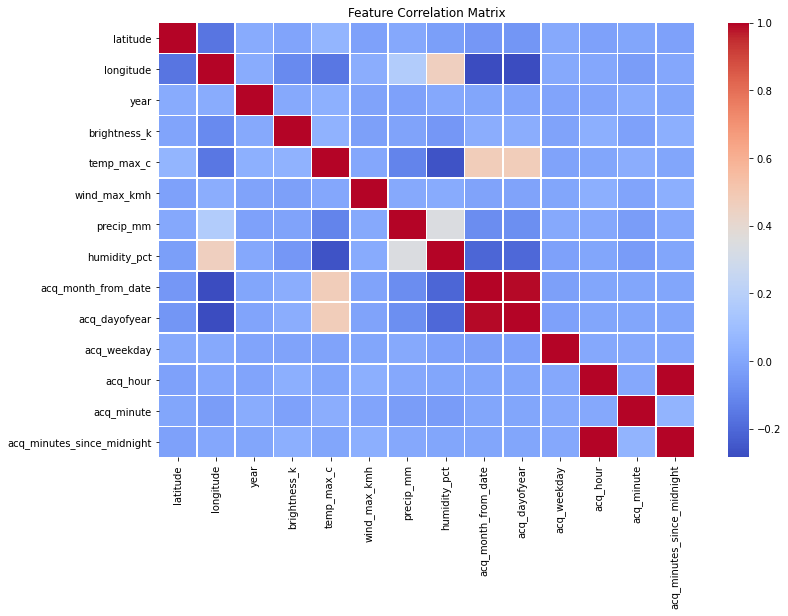

Feature correlations with the target:
brightness_k                  0.388928
longitude                     0.215381
humidity_pct                  0.163306
temp_max_c                    0.118841
acq_month_from_date           0.061498
acq_dayofyear                 0.061463
precip_mm                     0.059050
latitude                      0.029989
acq_minute                    0.021006
year                          0.013294
acq_minutes_since_midnight    0.009304
acq_hour                      0.008421
acq_weekday                   0.004600
wind_max_kmh                  0.002287
dtype: float64


In [35]:
import seaborn as sns

# Select only numeric columns for correlation analysis
numeric_cols = X_all.select_dtypes(include=[np.number])

# Ensure the target variable's index matches the feature DataFrame
y_aligned = y.reindex(X_all.index)

# Ensure y_aligned is numeric
y_aligned = pd.to_numeric(y_aligned, errors="coerce")

# Drop rows with NaN in y_aligned or numeric_cols
valid_indices = y_aligned.dropna().index
numeric_cols = numeric_cols.loc[valid_indices]
y_aligned = y_aligned.loc[valid_indices]

# Compute correlation matrix
corr_matrix = numeric_cols.corr()

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Matrix")
plt.show()

# Convert nullable Int64 columns to float64
numeric_cols = numeric_cols.astype("float64")

# Correlation with the target variable
target_corr = numeric_cols.corrwith(y_aligned)

# Sort by absolute correlation
target_corr = target_corr.abs().sort_values(ascending=False)

print("Feature correlations with the target:")
print(target_corr)

brightness_k, longtitude, and humidity_pct have the strong relations with the target. The wind_max_kmh has the lowest correlation with the target in the numeric columns.

## Leak-free preprocessing for model development

The following preprocessing steps are used for training and evaluation.  
To avoid data leakage, we first split the labeled data into train/validation/test, then fit preprocessing (imputation values, one-hot encoding column set, scaling) on the training set only, and apply the same transformations to validation/test and the submission set.

Train (60%): enough data to fit models reliably.
Validation (20%): enough samples to tune hyperparameters and compare models without touching the test set.
Test (20%): held out for an unbiased final performance estimate.
With imbalanced classes, using stratification keeps class proportions similar across splits, making macro-F1 more stable and comparable.

In [36]:
RANDOM_STATE = 0
target_col = "fire_intensity"

# Split labeled data FIRST (avoid leakage)
X_raw = df.drop(columns=[target_col])
y = y.astype(int)

X_train_raw, X_temp_raw, y_train, y_temp = train_test_split(
    X_raw, y, test_size=0.4, stratify=y, random_state=RANDOM_STATE
)
X_val_raw, X_test_raw, y_val, y_test = train_test_split(
    X_temp_raw, y_temp, test_size=0.5, stratify=y_temp, random_state=RANDOM_STATE
)

We do the feature engineer for each dataset

In [38]:
# Feature engineering
X_train = make_features(X_train_raw)
X_val   = make_features(X_val_raw)
X_test  = make_features(X_test_raw)
X_submit = make_features(df_test)

We impute the missing columns by using TRAIN dataset only.

In [39]:
num_missing_cols = ["brightness_k", "wind_max_kmh"]
fill_median = X_train[num_missing_cols].median()

for X_ in [X_train, X_val, X_test, X_submit]:
    X_[num_missing_cols] = X_[num_missing_cols].fillna(fill_median)

We convert categorial variables into binary columns by using one-hot encoding which ensures compatibility with models.

In [40]:
cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

X_train_oh = pd.get_dummies(X_train, columns=cat_cols, drop_first=False)
X_val_oh   = pd.get_dummies(X_val,   columns=cat_cols, drop_first=False).reindex(columns=X_train_oh.columns, fill_value=0)
X_test_oh  = pd.get_dummies(X_test,  columns=cat_cols, drop_first=False).reindex(columns=X_train_oh.columns, fill_value=0)
X_submit_oh= pd.get_dummies(X_submit,columns=cat_cols, drop_first=False).reindex(columns=X_train_oh.columns, fill_value=0)


We scale the dataset, it is needed for SVM and Neural Network.

In [41]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_oh)
X_val_scaled   = scaler.transform(X_val_oh)
X_test_scaled  = scaler.transform(X_test_oh)
X_submit_scaled= scaler.transform(X_submit_oh)

# C. Model Development and Performance Analysis

Evaluation Metrics:
- Use macro F1-score as the primary metric to handle class imbalance.


In [50]:

def get_acc_scores(clf, train_X, train_y, val_X, val_y):
    train_pred = clf.predict(train_X)
    val_pred = clf.predict(val_X)
    
    train_acc = f1_score(train_y, train_pred, average='macro')
    val_acc = f1_score(val_y, val_pred, average='macro')
    
    return train_acc, val_acc

### 3.1. Decision Tree


#### 3.1.1 Simple baseline

In [66]:

dt_base = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt_base.fit(X_train_oh, y_train)

yhat_train = dt_base.predict(X_train_oh)
yhat_val   = dt_base.predict(X_val_oh)

f1_train = f1_score(y_train, yhat_train, average="macro")
f1_val   = f1_score(y_val,   yhat_val,   average="macro")

print("Baseline DT")
print("Train macro-F1:", round(f1_train, 4))
print("Val   macro-F1:", round(f1_val, 4))


Baseline DT
Train macro-F1: 1.0
Val   macro-F1: 0.3695


Observation: Train macro - F1 is greater than val macro F1 which indicates that the model is overfitting.

#### 3.1.2. We explore the max_depth hyperparameter to see how it affects performance

Best val macro-F1 at max_depth = 13 with 0.3822


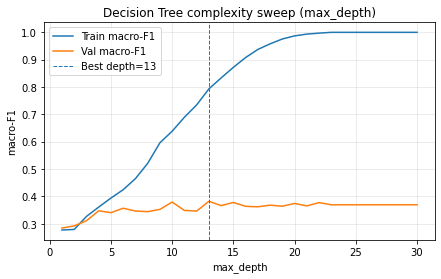

In [67]:

depths = list(range(1, 31))
train_f1s, val_f1s = [], []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE)
    dt.fit(X_train_oh, y_train)

    train_f1s.append(f1_score(y_train, dt.predict(X_train_oh), average="macro"))
    val_f1s.append(f1_score(y_val,   dt.predict(X_val_oh),   average="macro"))

best_d = depths[int(np.argmax(val_f1s))]
print("Best val macro-F1 at max_depth =", best_d, "with", round(max(val_f1s), 4))

plt.figure(figsize=(7,4))
plt.plot(depths, train_f1s, label="Train macro-F1")
plt.plot(depths, val_f1s, label="Val macro-F1")
plt.axvline(best_d, linestyle="--", linewidth=1, label=f"Best depth={best_d}")
plt.xlabel("max_depth")
plt.ylabel("macro-F1")
plt.title("Decision Tree complexity sweep (max_depth)")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

Observations: 
- while max_depth increases, the training macro-F1 reises sharply and approaches 1.0. That means deeper trees can fit the training set well.
- The validation macro-F1 improves only slightly and then plateaus.
- The widening gap between train and validation curves indicates overfitting at larger depths.

#### 3.1.3. Hyperparameter tuning with CV (extra hyperparameter: min_samples_leaf)

In [54]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV

# Keep validation set as a true hold-out for model selection reporting
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

param_grid = {
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_leaf": [1, 2, 5, 10, 20],     
    "min_samples_split": [2, 5, 10],
    "class_weight": [None, "balanced"],
}

dt = DecisionTreeClassifier(random_state=RANDOM_STATE)

grid = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    refit=True,
)

# IMPORTANT: fit ONLY on training data
grid.fit(X_train_oh, y_train)

print("Best CV macro-F1 (on training folds):", round(grid.best_score_, 4))
print("Best params:", grid.best_params_)

best_dt = grid.best_estimator_

train_f1, val_f1 = get_acc_scores(best_dt, X_train_oh, y_train, X_val_oh, y_val)
print("Train macro-F1 (best_dt):", round(train_f1, 4))
print("Val   macro-F1 (best_dt):", round(val_f1, 4))

Best CV macro-F1 (on training folds): 0.3716
Best params: {'class_weight': None, 'max_depth': 10, 'min_samples_leaf': 20, 'min_samples_split': 2}
Train macro-F1 (best_dt): 0.5283
Val   macro-F1 (best_dt): 0.3899


Observations: With these best parameters, train macro-F1 (0.5283) is still higher than validation macro-F1 (0.3899), indicating the tuned tree still overfits (generalization gap remains).

#### 3.1.4. Post-pruning via cost-complexity pruning (ccp_alpha)

Best ccp_alpha (by val macro-F1): 0.0 val macro-F1: 0.3899


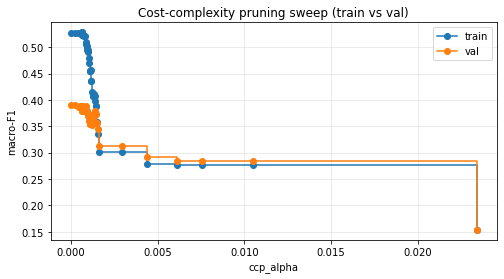

In [57]:
from sklearn import tree
import matplotlib.pyplot as plt

base_params = grid.best_params_.copy()

# 1) Pruning path from TRAIN only (no leakage)
clf0 = tree.DecisionTreeClassifier(random_state=RANDOM_STATE, **base_params)
path = clf0.cost_complexity_pruning_path(X_train_oh, y_train)

ccp_alphas = path.ccp_alphas

# 2) Train trees for each alpha, pick alpha by VALIDATION macro-F1
train_scores, val_scores = [], []

for a in ccp_alphas:
    clf = tree.DecisionTreeClassifier(
        random_state=RANDOM_STATE,
        ccp_alpha=float(a),
        **base_params,
    )
    clf.fit(X_train_oh, y_train)

    train_scores.append(f1_score(y_train, clf.predict(X_train_oh), average="macro"))
    val_scores.append(f1_score(y_val, clf.predict(X_val_oh), average="macro"))

best_i = int(np.argmax(val_scores))
best_alpha = float(ccp_alphas[best_i])

print("Best ccp_alpha (by val macro-F1):", best_alpha, "val macro-F1:", round(val_scores[best_i], 4))

plt.figure(figsize=(8,4))
plt.plot(ccp_alphas, train_scores, marker="o", label="train", drawstyle="steps-post")
plt.plot(ccp_alphas, val_scores, marker="o", label="val", drawstyle="steps-post")
plt.xlabel("ccp_alpha")
plt.ylabel("macro-F1")
plt.title("Cost-complexity pruning sweep (train vs val)")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

As ccp_alpha increases, the training macro-F1 drops sharply, showing that pruning is effectively reducing model complexility. Besides, the validation macro-F1 is highest at small ccp_alpha values, then declines as pruning become stronger, so aggressive pruning starts to underfit.


#### 3.1.5. — Final tree fit and visualization with top 3 levels only


Refit on training and validation data, then resue it

In [ ]:
X_dev = pd.concat([X_train_oh, X_val_oh], axis=0)
y_dev = pd.concat([y_train, y_val], axis=0)

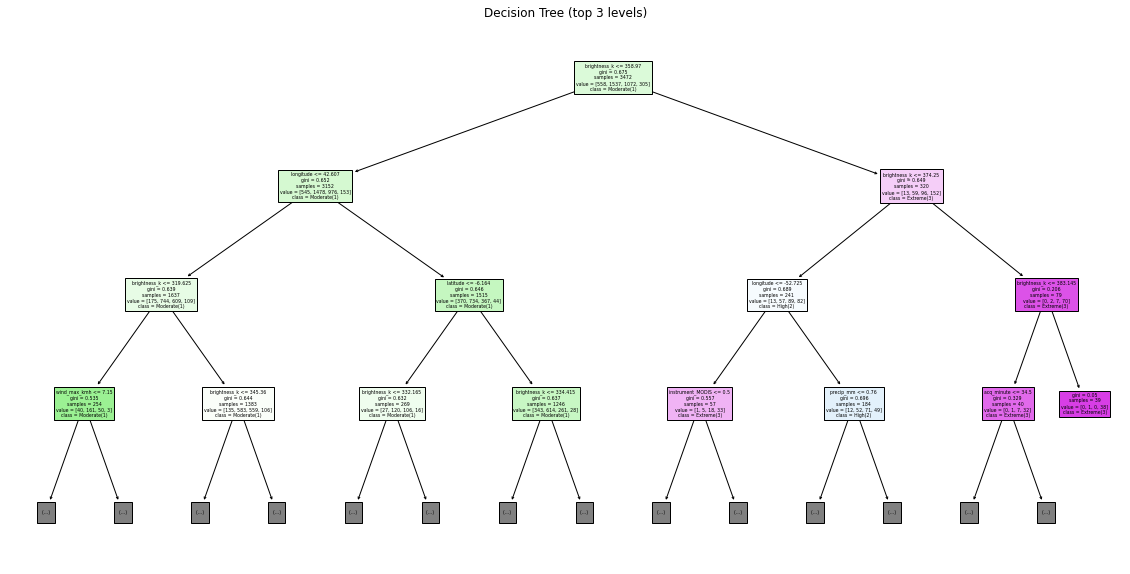

In [ ]:

final_dt = DecisionTreeClassifier(
    random_state=RANDOM_STATE,
    ccp_alpha=best_alpha,
    **base_params,
)
final_dt.fit(X_dev, y_dev)

plt.figure(figsize=(20, 10))
plot_tree(
    final_dt,
    feature_names=X_train_oh.columns,
    class_names=["Low(0)", "Moderate(1)", "High(2)", "Extreme(3)"],
    max_depth=3,
    filled=True,
)
plt.title("Decision Tree (top 3 levels)")
plt.show()

- The top levels split first on a small set of features, which means those variables provide the biggest impurity reduction.
- The early slits mainly separate the majority class first, while the minority classes appear deeper in the tree.

### 3.2.Support Vector Machine (SVM)

#### 3.2.1. Compare kernels (linear vs RBF)


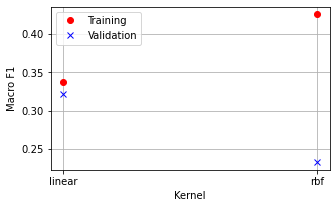

[('linear', 0.3371413895391659, 0.32149760058874766), ('rbf', 0.42543165295088275, 0.23253433935981732)]


In [77]:


kernels = ["linear", "rbf"]
train_perf, val_perf = [], []

C0 = 2.0

for kernel in kernels:
    clf = SVC(kernel=kernel, C=C0)
    clf.fit(X_train_scaled, y_train)

    train_f1 = f1_score(y_train, clf.predict(X_train_scaled), average="macro")
    val_f1   = f1_score(y_val,   clf.predict(X_val_scaled),   average="macro")

    train_perf.append(train_f1)
    val_perf.append(val_f1)

plt.figure(figsize=(5,3))
plt.plot(kernels, train_perf, "ro", label="Training")
plt.plot(kernels, val_perf, "bx", label="Validation")
plt.ylabel("Macro F1")
plt.xlabel("Kernel")
plt.grid(True)
plt.legend()
plt.show()

print(list(zip(kernels, train_perf, val_perf)))

Linear kernel: train and validation macro-F1 are close, which shows that it is not overfitting. However, the absolute macro-F1 is only moderate.
RBF kernel: training macro‑F1 is noticeably higher than validation macro‑F1, indicating with current settings.

#### 3.2.2. Regularization (effect of C on train vs val)


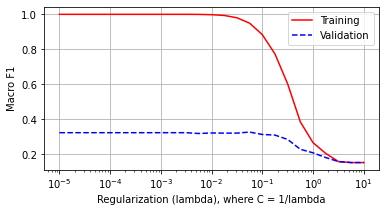

In [78]:
lambda_params = np.logspace(-5, 1, num=25) 

train_perf, val_perf = [], []

for lam in lambda_params:
    C = 1.0 / lam
    clf = SVC(kernel="rbf", C=C)
    clf.fit(X_train_scaled, y_train)

    train_perf.append(f1_score(y_train, clf.predict(X_train_scaled), average="macro"))
    val_perf.append(f1_score(y_val,   clf.predict(X_val_scaled),   average="macro"))

plt.figure(figsize=(6,3))
plt.plot(lambda_params, train_perf, "r-", label="Training")
plt.plot(lambda_params, val_perf,   "b--", label="Validation")
plt.xscale("log")
plt.xlabel("Regularization (lambda), where C = 1/lambda")
plt.ylabel("Macro F1")
plt.grid(True)
plt.legend()
plt.show()

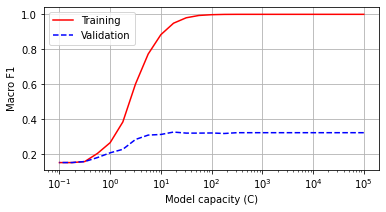

Best C by validation macro-F1: 17.78279410038923 val macro-F1: 0.3277


In [79]:
plt.figure(figsize=(6,3))
plt.plot(1/lambda_params, train_perf, "r-", label="Training")
plt.plot(1/lambda_params, val_perf,   "b--", label="Validation")
plt.xscale("log")
plt.xlabel("Model capacity (C)")
plt.ylabel("Macro F1")
plt.grid(True)
plt.legend()
plt.show()

best_i = int(np.argmax(val_perf))
best_C = float(1/lambda_params[best_i])
print("Best C by validation macro-F1:", best_C, "val macro-F1:", round(val_perf[best_i], 4))

- As C increases, the training macro-F1 rises rapidly and approaches 1.0, which mean it fits the training well. 
- The validation macro-F1 improves only slightly and then plateaus, training and validation have the widen gap with large C.

#### 3.2.3. Extra hyperparameter (gamma)

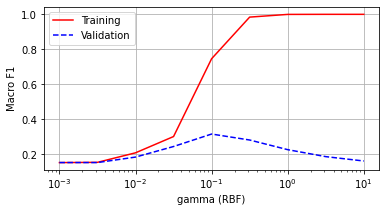

Best gamma: 0.1 val macro-F1: 0.3164


In [74]:
gamma_list = np.logspace(-3, 1, num=9)  # 1e-3 ... 1e1

train_perf_g, val_perf_g = [], []

for g in gamma_list:
    clf = SVC(kernel="rbf", C=best_C, gamma=g)
    clf.fit(X_train_scaled, y_train)

    train_perf_g.append(f1_score(y_train, clf.predict(X_train_scaled), average="macro"))
    val_perf_g.append(f1_score(y_val,   clf.predict(X_val_scaled),   average="macro"))

plt.figure(figsize=(6,3))
plt.plot(gamma_list, train_perf_g, "r-", label="Training")
plt.plot(gamma_list, val_perf_g,   "b--", label="Validation")
plt.xscale("log")
plt.xlabel("gamma (RBF)")
plt.ylabel("Macro F1")
plt.grid(True)
plt.legend()
plt.show()

best_i = int(np.argmax(val_perf_g))
best_gamma = float(gamma_list[best_i])
print("Best gamma:", best_gamma, "val macro-F1:", round(val_perf_g[best_i], 4))

As gammad increases, training macro-F1 rises quickly and approaches 1.0, showing higher capacity.
Validation macro-F1 peaks around a moderate gamma (1/10). Then it declines as gamma become large which indicates overfitting.

#### 3.2.4. Cross validation

In [ ]:
from sklearn.pipeline import Pipeline

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

pipe = Pipeline([
    ("scaler", MinMaxScaler()),
    ("svm", SVC()),
])

param_grid = [
    {
        "svm__kernel": ["linear"],
        "svm__C": [0.01, 0.1, 1, 10, 100],
    },
    {
        "svm__kernel": ["rbf"],
        "svm__C": [0.1, 1, 10, 100],
        "svm__gamma": [1e-3, 1e-2, 1e-1, 1],   # extra hyperparameter (decision boundary)
    },
]

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    refit=True,
)

grid.fit(X_train_oh, y_train)

print("Best CV macro-F1 (training folds):", round(grid.best_score_, 4))
print("Best params:", grid.best_params_)

# Evaluate once on validation hold-out
best_svm = grid.best_estimator_
train_f1 = f1_score(y_train, best_svm.predict(X_train_oh), average="macro")
val_f1   = f1_score(y_val,   best_svm.predict(X_val_oh),   average="macro")
print("Train macro-F1:", round(train_f1, 4))
print("Val   macro-F1:", round(val_f1, 4))

Best CV macro-F1 (training folds): 0.3208
Best params: {'svm__C': 100, 'svm__kernel': 'linear'}
Train macro-F1: 0.3797
Val   macro-F1: 0.3688


Showing the small generalization gap but performance is moderate.

#### 3.2.5. Refit on Train + Val after choosing the best parameters

In [80]:
from sklearn.base import clone

final_svm = clone(best_svm).fit(X_dev, y_dev)  # refit a fresh copy on train+val

### Neural Network